<a href="https://colab.research.google.com/github/EstevaoMO/machine-learning-aprendizadodemaquina/blob/main/02_dados_e_preprocessamento/colabs/Codifica%C3%A7%C3%A3o_de_Vari%C3%A1veis_Categ%C3%B3ricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Codificação de Variáveis Categóricas

## 1. Apresentação do Problema

Algoritmos de aprendizado de máquina operam exclusivamente sobre espaços vetoriais numéricos. Isso significa que qualquer variável qualitativa precisa ser **traduzida** para uma representação numérica antes de entrar no modelo; e a escolha errada dessa tradução pode introduzir vieses que corrompem silenciosamente o aprendizado.

Neste laboratório vamos aprender **quando e por que** usar cada estratégia de codificação, observando os efeitos diretamente nos erros dos modelos.

---

### dataset

Usaremos o dataset `tips`, que registra informações sobre refeições em um restaurante americano. Nosso objetivo será prever o **valor da gorjeta** (`tip`); um problema de regressão.

| Coluna | Tipo | Natureza |
|---|---|---|
| `total_bill` | Numérica contínua | Valor total da conta |
| `size` | Numérica ordinal | Tamanho da mesa (1–6 pessoas) |
| `time` | Categórica **ordinal** | `Lunch` < `Dinner` |
| `day` | Categórica **nominal** | Dia da semana (sem hierarquia natural) |
| `smoker` | Binária | Seção fumante ou não |
| `sex` | Binária | Sexo do pagador |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [4]:
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

df = sns.load_dataset('tips')

print(f"Shape: {df.shape}")
print(f"\nTipos originais:\n{df.dtypes}\n")
display(df.head(8))

Shape: (244, 7)

Tipos originais:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4


## 2. Codificação Ordinal

O `OrdinalEncoder` substitui cada categoria por um inteiro segundo uma ordem **que você define explicitamente**. O modelo receberá números que preservam a relação de magnitude entre as categorias.

**Critério de uso:** aplique apenas quando existir uma hierarquia semântica real e **verificável nos dados**.

Antes de qualquer codificação, precisamos validar se a ordenação que pretendemos impor tem respaldo empírico.

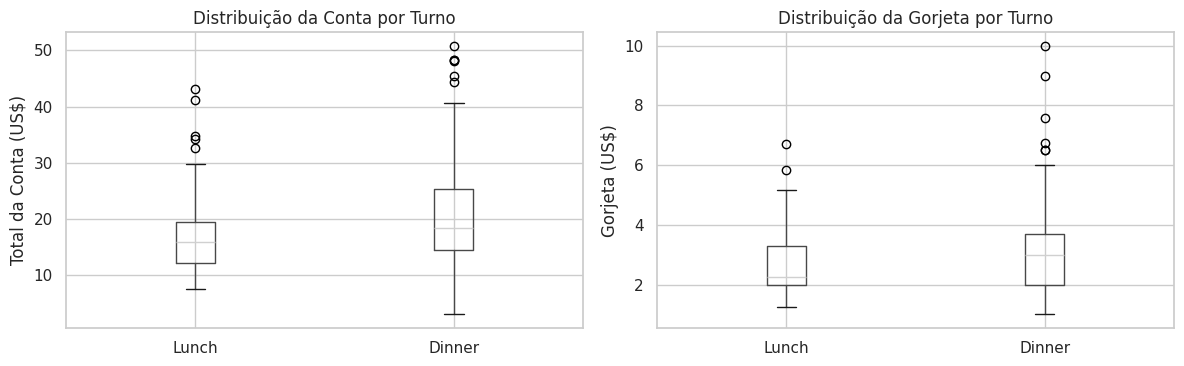

       total_bill                tip             
             mean median count  mean median count
time                                             
Lunch       17.17  15.96    68  2.73   2.25    68
Dinner      20.80  18.39   176  3.10   3.00   176

Teste Mann-Whitney (total_bill, bilateral): p = 0.0012

→ Diferença estatisticamente significativa (α = 0.05)
→ Mas atenção: Dinner tem 176 observações vs. 68 de Lunch, então o desequilíbrio deve ser considerado.
→ A ordenação Lunch < Dinner é defensável nesta base, mas não é uma verdade universal.


/tmp/ipykernel_2714/3716654718.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('time')[['total_bill', 'tip']].agg(['mean', 'median', 'count']).round(2))


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição de total_bill por turno
df.boxplot(column='total_bill', by='time', ax=axes[0])
axes[0].set_title('Distribuição da Conta por Turno')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total da Conta (US$)')

# Distribuição de tip por turno
df.boxplot(column='tip', by='time', ax=axes[1])
axes[1].set_title('Distribuição da Gorjeta por Turno')
axes[1].set_xlabel('')
axes[1].set_ylabel('Gorjeta (US$)')

plt.suptitle('')
plt.tight_layout()
plt.show()

from scipy import stats

lunch_bill  = df[df['time'] == 'Lunch']['total_bill']
dinner_bill = df[df['time'] == 'Dinner']['total_bill']

_, p = stats.mannwhitneyu(dinner_bill, lunch_bill, alternative='two-sided')

print(df.groupby('time')[['total_bill', 'tip']].agg(['mean', 'median', 'count']).round(2))
print(f"\nTeste Mann-Whitney (total_bill, bilateral): p = {p:.4f}")
print(f"\n→ {'Diferença estatisticamente significativa' if p < 0.05 else 'Diferença NÃO significativa'} (α = 0.05)")
print(  "→ Mas atenção: Dinner tem 176 observações vs. 68 de Lunch, então o desequilíbrio deve ser considerado.")
print(  "→ A ordenação Lunch < Dinner é defensável nesta base, mas não é uma verdade universal.")

## Conclusão da Hipótese
Com a hipótese verificada nos dados, a codificação ordinal de `time` se justifica **para este dataset**:

- `time`: Dinner apresenta contas e gorjetas sistematicamente maiores que Lunch nesta amostra (p = 0.0012, Mann-Whitney). A ordem `Lunch=0, Dinner=1` é defensável.

- `day`: Não existe ordenação natural entre dias da semana verificável nos dados, por isso impor uma seria inventar uma relação que o modelo trataria como fato.

A lição é que **qualquer hipótese de
ordenação deve ser testada na sua base específica antes de ser codificada**.

In [11]:
"""
Demonstração do impacto da escolha de codificação ordinal.

Comparamos o uso correto (hierarquia verificada) com um erro plausível:
mapear dias da semana em ordem cronológica, como se fossem progressivamente
mais relevantes, o que não existe nesta variável.
"""

ordem_cronologica = [['Thur', 'Fri', 'Sat', 'Sun']]

enc_time = OrdinalEncoder(categories=[['Lunch', 'Dinner']])
enc_day  = OrdinalEncoder(categories=ordem_cronologica)

demo = df[['time', 'day']].drop_duplicates().copy()
demo['time_cod'] = enc_time.fit_transform(demo[['time']])
demo['day_cod']  = enc_day.fit_transform(demo[['day']])

print("time, com hierarquia verificada nos dados (Lunch=0 < Dinner=1):")
print(demo[['time', 'time_cod']].drop_duplicates().sort_values('time_cod').to_string(index=False))

print("\nday, com ordem cronológica imposta (Thur=0, Fri=1, Sat=2, Sun=3):")
print(demo[['day', 'day_cod']].sort_values('day_cod').to_string(index=False))

print("\nO modelo interpretaria domingo como 3x mais relevante que quinta, uma relação fundamentalmente inexistente.")

time, com hierarquia verificada nos dados (Lunch=0 < Dinner=1):
  time  time_cod
 Lunch       0.0
Dinner       1.0

day, com ordem cronológica imposta (Thur=0, Fri=1, Sat=2, Sun=3):
 day  day_cod
Thur      0.0
Thur      0.0
 Fri      1.0
 Fri      1.0
 Sat      2.0
 Sun      3.0

O modelo interpretaria domingo como 3x mais relevante que quinta, uma relação fundamentalmente inexistente.


## 3. One-Hot Encoding, variáveis nominais

Para variáveis sem hierarquia, o **One-Hot Encoding** cria uma coluna binária por categoria, sem impor nenhuma relação de ordem entre elas.

O parâmetro `drop='first'` remove uma coluna redundante; se sabemos que não é Sexta, Sábado nem Domingo, já concluímos que é Quinta.

**A armadilha da alta dimensionalidade:** aplicar OHE em uma variável contínua como `total_bill` transforma cada valor único em uma coluna binária, gerando dezenas de colunas esparsas. Em modelos baseados em distância como o KNN, isso dilui o conceito de "vizinhança" e degrada a generalização.

In [7]:
enc_ohe = OneHotEncoder(drop='first', sparse_output=False)
day_ohe = pd.DataFrame(
    enc_ohe.fit_transform(df[['day']]),
    columns=enc_ohe.get_feature_names_out(['day']),
    index=df.index
)

# OHE incorreto, em total_bill
bill_int = df[['total_bill']].round(0).astype(int) # traduzindo para int para facilitar a codificação
enc_bill = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

bill_ohe = pd.DataFrame(enc_bill.fit_transform(bill_int), index=df.index)
bill_ohe.columns = bill_ohe.columns.astype(str)

print(f"OHE em 'day'\n {day_ohe.shape[1]} colunas (4 categorias, drop='first')")
print(f"\nOHE em 'total_bill'\n {bill_ohe.shape[1]} colunas (uma por valor único)")

OHE em 'day'
 3 colunas (4 categorias, drop='first')

OHE em 'total_bill'
 41 colunas (uma por valor único)


## 4. Comparativo do impacto das decisões de codificação

Vamos treinar um KNN em quatro cenários e comparar o MAE no treino e no teste.

| Cenário | Descrição |
|---|---|
| **A. Correto** | OHE em `day` e ordinais corretamente aplicados |
| **B. Day ordinal errado** | `day` codificado 0–3 em ordem cronológica |
| **D. OHE em total_bill** | Variável contínua explodida em 48 colunas |

In [16]:
enc_day_errado = OrdinalEncoder(categories=[['Thur', 'Fri', 'Sat', 'Sun']])
df['day_ord_errado'] = enc_day_errado.fit_transform(df[['day']])

# Encoders corretos
enc_time = OrdinalEncoder(categories=[['Lunch', 'Dinner']])
df['time_cod'] = enc_time.fit_transform(df[['time']])
enc_sex = OrdinalEncoder(categories=[['Female', 'Male']])
df['sex_cod'] = enc_sex.fit_transform(df[['sex']])
enc_smoker = OrdinalEncoder(categories=[['No', 'Yes']])
df['smoker_cod'] = enc_smoker.fit_transform(df[['smoker']])

y = df['tip'] # alvo
base = df[['total_bill', 'size', 'sex_cod', 'smoker_cod', 'time_cod']]

X_A = pd.concat([base, day_ohe], axis=1)
X_B = pd.concat([base, df[['day_ord_errado']]], axis=1)
X_D = pd.concat([df[['size', 'sex_cod', 'smoker_cod', 'time_cod']], day_ohe, bill_ohe], axis=1)

def avaliar(X, y):
    X = X.copy(); X.columns = X.columns.astype(str)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lreg = LinearRegression().fit(X_train, y_train)
    return {
        'MAE Treino': mean_absolute_error(y_train, lreg.predict(X_train)),
        'MAE Teste':  mean_absolute_error(y_test,  lreg.predict(X_test)),
        'N features': X.shape[1]
    }

resultados = {
    'A. Corretos': avaliar(X_A, y),
    'B. Ordinal errado': avaliar(X_B, y),
    'D. One-Hot Encoding em total_bill':  avaliar(X_D, y),
}

df_res = pd.DataFrame(resultados).T
display(df_res.round(3))

,MAE Treino,MAE Teste,N features
A. Corretos,0.760,0.667,8.0
B. Ordinal errado,0.763,0.669,6.0
D. One-Hot Encoding em total_bill,0.636,0.773,48.0


> Perceba como, no primeiro caso (A), o erro médio no treino foi maior, mas no teste o rendimento subiu, demonstrando que o modelo aprendeu e foi **capaz de generalizar no caso de teste**. No caso (B), o **erro aumentou** um pouco. Como apenas uma dimensão estava mal-estruturada, o impacto não foi tão grande; mas considere essa má escolha de engenharia de dados em mais colunas, e o problema será consideravelmente maior.

> No entanto, no caso (C), veja como alcançamos uma situação curiosa. O modelo foi **muito melhor no treino** que todos os outros dois (A e B), mas no teste real sua performance foi a pior. **Por que você acha que isso aconteceu?** Foi o que falamos anteriormente, ele **"decorou" padrões** por conta da nossa má escolha de engenharia, e por isso se destacou no treino. No entanto, nos testes, **não apresentou boa capacidade de generalização.** Esse é o famoso caso de **overfitting** que já mencionamos no curso, e no próximo módulo iremos discutir mais a fundo.